# Actuable Eye Camera Demo

This notebook demonstrates and validates the actuable eye camera system for the
virtual rodent. The rodent has 2 yaw hinge joints on the skull that allow the
RL agent to actively control where each eye is looking.

Key features:
- Eye actuators are the **last 2 entries** in the action vector
- Positive control = "look outward" for both eyes (symmetric axis convention)
- Camera names: `eye_left_actuated-rodent`, `eye_right_actuated-rodent`
- Eye joint angles are appended to `task_obs` (last 2 values)

## 1. Setup + Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [2]:
import jax
import jax.numpy as jp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from vnl_playground.tasks.rodent.run_gap_vision import RunGapVision, default_config
from vnl_playground.tasks.rodent.vision_jax import JaxVisionRenderer
from mujoco.mjx.warp.types import DATA_NON_VMAP


def add_batch_dim(data):
    """Add a leading nworld=1 dimension to mjx.Data, skipping non-vmap fields."""

    def _maybe_expand(path, x):
        parts = [p.name for p in path if hasattr(p, "name") and p.name != "_impl"]
        attr = "__".join(parts)
        if attr in DATA_NON_VMAP:
            return x
        return x[None, ...]

    return jax.tree.map_with_path(_maybe_expand, data)


print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


## 2. Create Actuable Eye Environment

In [3]:
cfg = default_config()
cfg.actuable_eyes = True
cfg.binocular = True
cfg.mujoco_impl = "warp"
cfg.use_mesh_platforms = True
cfg.aesthetic = "outdoor_natural"

env = RunGapVision(config=cfg)

print(f"Action size (total):     {env.action_size}")
print(f"N eye actuators:         {env.n_eye_actuators}")
print(f"Body actuators:          {env.action_size - env.n_eye_actuators}")
print(f"Eye yaw range:           +/-{np.degrees(cfg.eye_yaw_range):.1f} deg")
print(f"Left camera name:        {cfg.left_camera_name}")
print(f"Right camera name:       {cfg.right_camera_name}")
print()

# Print eye joint names from the MuJoCo model
import mujoco as mj

m = env.mj_model
print("Eye joints in model:")
for i in range(m.njnt):
    name = mj.mj_id2name(m, mj.mjtObj.mjOBJ_JOINT, i)
    if name and "eye" in name:
        qpos_addr = m.jnt_qposadr[i]
        print(f"  {name}  (joint id={i}, qpos addr={qpos_addr})")

Warp 1.13.0.dev20260302 initialized:
   Git commit: 2675d53530597430af87c7425a1bbb40a2c5453a
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 5090" (31 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.13.0.dev20260302
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Action size (total):     40
N eye actuators:         2
Body actuators:          38
Eye yaw range:           +/-40.0 deg
Left camera name:        eye_left_actuated-rodent
Right camera name:       eye_right_actuated-rodent

Eye joints in model:
  eye_left_yaw-rodent  (joint id=62, qpos addr=68)
  eye_right_yaw-rodent  (joint id=63, qpos addr=69)


In [4]:
# Create JaxVisionRenderers for left and right actuated cameras
WIDTH, HEIGHT = 64, 64
NWORLD = 1

renderer_left = JaxVisionRenderer(
    mj_model=env.mj_model,
    mjx_model=env.mjx_model,
    nworld=NWORLD,
    width=WIDTH,
    height=HEIGHT,
    grayscale=False,
    render_depth=False,
    use_textures=True,
    use_shadows=True,
    camera_name="eye_left_actuated-rodent",
)

renderer_right = JaxVisionRenderer(
    mj_model=env.mj_model,
    mjx_model=env.mjx_model,
    nworld=NWORLD,
    width=WIDTH,
    height=HEIGHT,
    grayscale=False,
    render_depth=False,
    use_textures=True,
    use_shadows=True,
    camera_name="eye_right_actuated-rodent",
)

# JIT compile renderers
render_left_jit = jax.jit(renderer_left.render)
render_right_jit = jax.jit(renderer_right.render)

print(f"Renderers created at {WIDTH}x{HEIGHT} RGB")

Module mujoco.mjx.third_party.mujoco_warp._src.render_util 9cda0d9 load on device 'cuda:0' took 1.39 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.io 4ae9eac load on device 'cuda:0' took 2.55 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.bvh 4527052 load on device 'cuda:0' took 1.74 ms  (cached)
Renderers created at 64x64 RGB


## 3. Baseline: Eyes Straight Ahead

Reset the environment, run 30 zero-action steps to let the rodent settle into a
natural pose, then render both eye views. With zero eye control, the eyes should
point straight ahead (joint angles ~0).

Module mujoco.mjx.warp.ffi 98d2031 load on device 'cuda:0' took 1.14 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 12773d5 load on device 'cuda:0' took 6.15 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 2.50 ms  (cached)
Module _nxn_broadphase__locals__kernel_ea6098d7 ea6098d load on device 'cuda:0' took 1.04 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_ba2335e3 ba2335e load on device 'cuda:0' took 3.16 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_47e99e6d 47e99e6 load on device 'cuda:0' took 1.34 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_201d3c22 201d3c2 load on device 'cuda:0' took 1.14 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_4d39dd93 4d39dd9 load on device 'cuda:0' took 1.45 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_f0f83fea f0f83fe load on device 'cuda:0' took 1.63 ms  (cached)
Module _primitive_narrowphase__locals

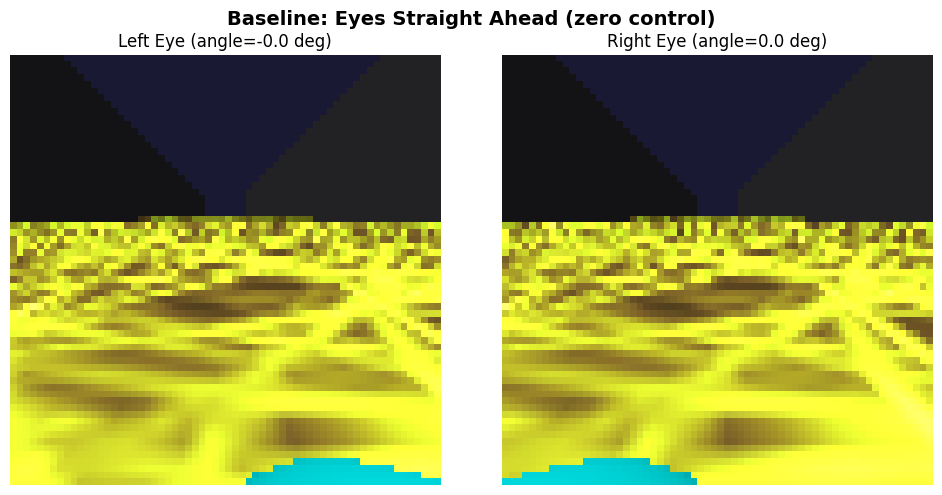

In [5]:
rng = jax.random.PRNGKey(42)
state = jax.jit(env.reset)(rng)
step_fn = jax.jit(env.step)

# Run 30 zero-action steps to get a natural pose
for _ in range(30):
    state = step_fn(state, jp.zeros(env.action_size))

# Render both eyes
batched_data = add_batch_dim(state.data)
img_left = np.array(render_left_jit(batched_data)[0])
img_right = np.array(render_right_jit(batched_data)[0])

# Extract eye joint angles from qpos
eye_angles = np.array(state.data.qpos[env._eye_qpos_indices])
print(
    f"Eye joint angles (radians): left={eye_angles[0]:.4f}, right={eye_angles[1]:.4f}"
)
print(
    f"Eye joint angles (degrees): left={np.degrees(eye_angles[0]):.2f}, right={np.degrees(eye_angles[1]):.2f}"
)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_left)
axes[0].set_title(f"Left Eye (angle={np.degrees(eye_angles[0]):.1f} deg)", fontsize=12)
axes[0].axis("off")

axes[1].imshow(img_right)
axes[1].set_title(f"Right Eye (angle={np.degrees(eye_angles[1]):.1f} deg)", fontsize=12)
axes[1].axis("off")

plt.suptitle(
    "Baseline: Eyes Straight Ahead (zero control)", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 4. Eye Control Demo: Diverge, Converge, Asymmetric

Test different eye control signals and visualize how the camera views change.
Recall that positive control = "look outward" for both eyes (symmetric axis convention).

In [6]:
# Define eye control conditions
# Each entry: (label, [left_eye_ctrl, right_eye_ctrl])
EYE_CONDITIONS = [
    ("Eyes straight", [0.0, 0.0]),
    ("Eyes diverge\n(look outward)", [1.0, 1.0]),
    ("Eyes converge\n(look inward)", [-1.0, -1.0]),
    ("Left only\noutward", [1.0, 0.0]),
    ("Right only\noutward", [0.0, 1.0]),
]

N_STEPS = 50  # steps to apply eye control
n_body_actuators = env.action_size - env.n_eye_actuators

condition_results = []  # list of (label, img_left, img_right, eye_angles)

for label, eye_ctrl in tqdm(EYE_CONDITIONS, desc="Eye conditions"):
    # Reset environment
    state = jax.jit(env.reset)(rng)

    # Build action: body actuators = 0, eye actuators = specified
    action = jp.zeros(env.action_size)
    action = action.at[-2].set(eye_ctrl[0])  # left eye
    action = action.at[-1].set(eye_ctrl[1])  # right eye

    # Run N_STEPS with this eye control
    for _ in range(N_STEPS):
        state = step_fn(state, action)

    # Render both eyes
    batched_data = add_batch_dim(state.data)
    img_l = np.array(render_left_jit(batched_data)[0])
    img_r = np.array(render_right_jit(batched_data)[0])

    # Extract eye joint angles
    angles = np.array(state.data.qpos[env._eye_qpos_indices])

    condition_results.append((label, img_l, img_r, angles))
    print(
        f"  {label.replace(chr(10), ' ')}: left={np.degrees(angles[0]):.2f} deg, right={np.degrees(angles[1]):.2f} deg"
    )

print("Done.")

Eye conditions:  20%|██        | 1/5 [00:02<00:09,  2.39s/it]

  Eyes straight: left=-0.00 deg, right=0.00 deg


Eye conditions:  40%|████      | 2/5 [00:04<00:06,  2.30s/it]

  Eyes diverge (look outward): left=39.99 deg, right=39.99 deg


Eye conditions:  60%|██████    | 3/5 [00:06<00:04,  2.26s/it]

  Eyes converge (look inward): left=-39.99 deg, right=-39.99 deg


Eye conditions:  80%|████████  | 4/5 [00:09<00:02,  2.26s/it]

  Left only outward: left=39.99 deg, right=0.00 deg


Eye conditions: 100%|██████████| 5/5 [00:11<00:00,  2.27s/it]

  Right only outward: left=0.00 deg, right=39.99 deg
Done.


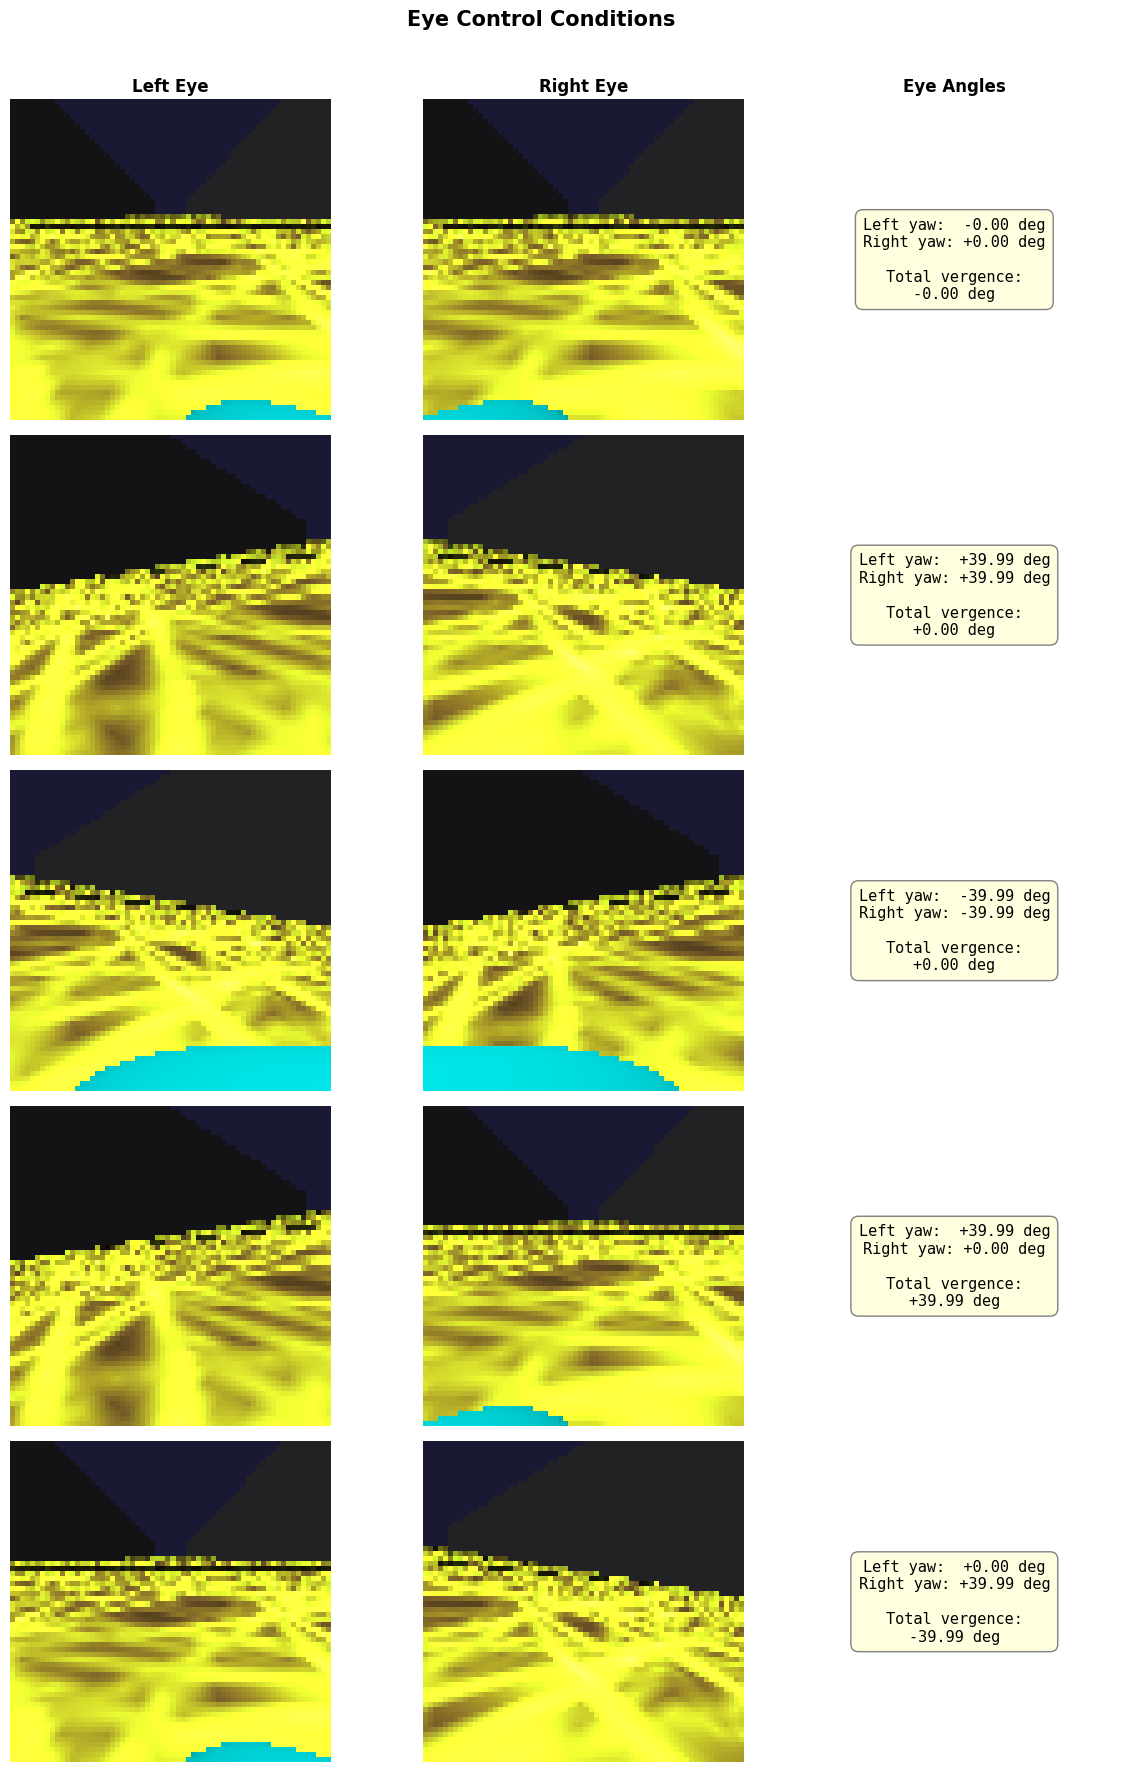

In [7]:
# Plot grid: rows = conditions, columns = [Left Eye, Right Eye, Eye Angles]
n_cond = len(condition_results)
fig, axes = plt.subplots(
    n_cond, 3, figsize=(12, 3.5 * n_cond), gridspec_kw={"width_ratios": [1, 1, 0.8]}
)

for row, (label, img_l, img_r, angles) in enumerate(condition_results):
    # Left eye
    axes[row, 0].imshow(img_l)
    axes[row, 0].axis("off")
    if row == 0:
        axes[row, 0].set_title("Left Eye", fontsize=12, fontweight="bold")

    # Right eye
    axes[row, 1].imshow(img_r)
    axes[row, 1].axis("off")
    if row == 0:
        axes[row, 1].set_title("Right Eye", fontsize=12, fontweight="bold")

    # Eye angles text panel
    axes[row, 2].axis("off")
    angle_text = (
        f"Left yaw:  {np.degrees(angles[0]):+.2f} deg\n"
        f"Right yaw: {np.degrees(angles[1]):+.2f} deg\n"
        f"\nTotal vergence:\n{np.degrees(angles[0] - angles[1]):+.2f} deg"
    )
    axes[row, 2].text(
        0.5,
        0.5,
        angle_text,
        transform=axes[row, 2].transAxes,
        ha="center",
        va="center",
        fontsize=11,
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="gray"),
    )
    if row == 0:
        axes[row, 2].set_title("Eye Angles", fontsize=12, fontweight="bold")

    # Row label
    axes[row, 0].set_ylabel(
        label, fontsize=11, fontweight="bold", rotation=0, labelpad=80, va="center"
    )

plt.suptitle("Eye Control Conditions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 5. Eye Movement Over Time

Apply a sinusoidal eye control signal that oscillates between convergence and
divergence over 100 steps. This demonstrates smooth, continuous eye movement.

In [8]:
N_TOTAL = 100
SAMPLE_STEPS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

# Reset environment
state = jax.jit(env.reset)(rng)

# Storage
eye_angle_history = np.zeros((N_TOTAL, 2))  # [left_yaw, right_yaw] per step
eye_ctrl_history = np.zeros(N_TOTAL)
sampled_frames_left = {}
sampled_frames_right = {}

for t in tqdm(range(N_TOTAL), desc="Sinusoidal eye sweep"):
    # Sinusoidal control: oscillates between -1 (converge) and +1 (diverge)
    eye_ctrl = np.sin(2 * np.pi * t / 50)
    eye_ctrl_history[t] = eye_ctrl

    # Build action
    action = jp.zeros(env.action_size)
    action = action.at[-2].set(eye_ctrl)  # left eye
    action = action.at[-1].set(eye_ctrl)  # right eye (same signal = symmetric)

    state = step_fn(state, action)

    # Record eye angles
    angles = np.array(state.data.qpos[env._eye_qpos_indices])
    eye_angle_history[t] = angles

    # Render at sample steps
    if t in SAMPLE_STEPS:
        batched_data = add_batch_dim(state.data)
        sampled_frames_left[t] = np.array(render_left_jit(batched_data)[0])
        sampled_frames_right[t] = np.array(render_right_jit(batched_data)[0])

print(f"Recorded {N_TOTAL} steps, rendered {len(SAMPLE_STEPS)} frames.")

Sinusoidal eye sweep: 100%|██████████| 100/100 [00:04<00:00, 23.13it/s]


Recorded 100 steps, rendered 10 frames.


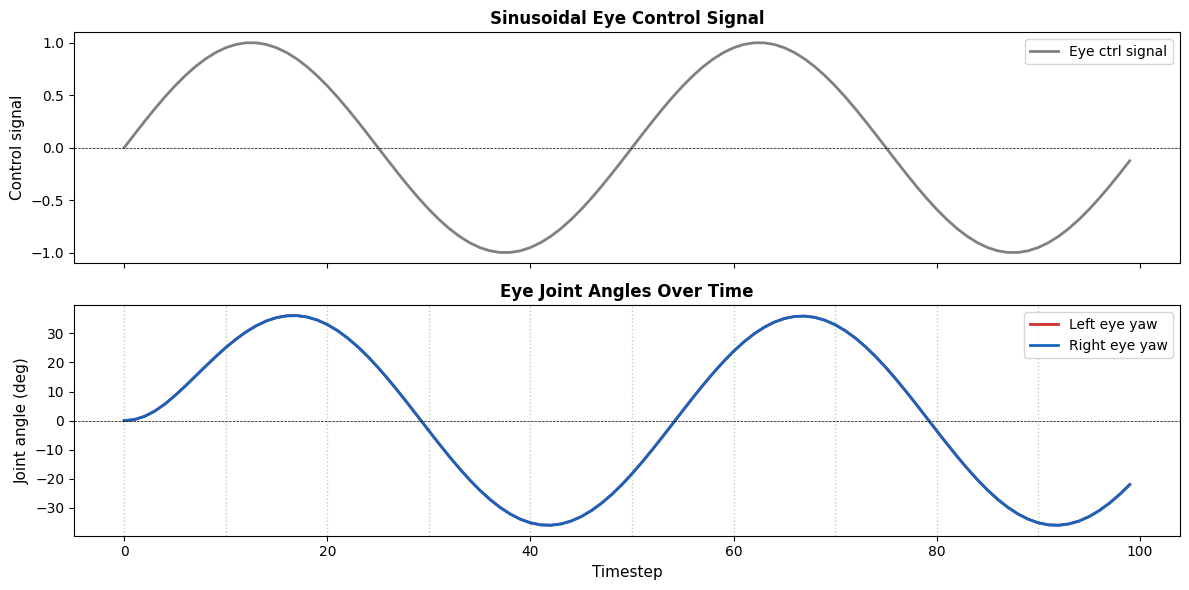

In [9]:
# Plot 1: Eye joint angle traces over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

timesteps = np.arange(N_TOTAL)

# Control signal
ax1.plot(
    timesteps, eye_ctrl_history, color="gray", linewidth=2, label="Eye ctrl signal"
)
ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax1.set_ylabel("Control signal", fontsize=11)
ax1.legend(fontsize=10)
ax1.set_title("Sinusoidal Eye Control Signal", fontsize=12, fontweight="bold")

# Eye angles
ax2.plot(
    timesteps,
    np.degrees(eye_angle_history[:, 0]),
    color="#D32F2F",
    linewidth=2,
    label="Left eye yaw",
)
ax2.plot(
    timesteps,
    np.degrees(eye_angle_history[:, 1]),
    color="#1565C0",
    linewidth=2,
    label="Right eye yaw",
)
ax2.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax2.set_xlabel("Timestep", fontsize=11)
ax2.set_ylabel("Joint angle (deg)", fontsize=11)
ax2.legend(fontsize=10)
ax2.set_title("Eye Joint Angles Over Time", fontsize=12, fontweight="bold")

# Mark sample steps
for t in SAMPLE_STEPS:
    ax2.axvline(t, color="green", alpha=0.3, linewidth=1, linestyle=":")

plt.tight_layout()
plt.show()

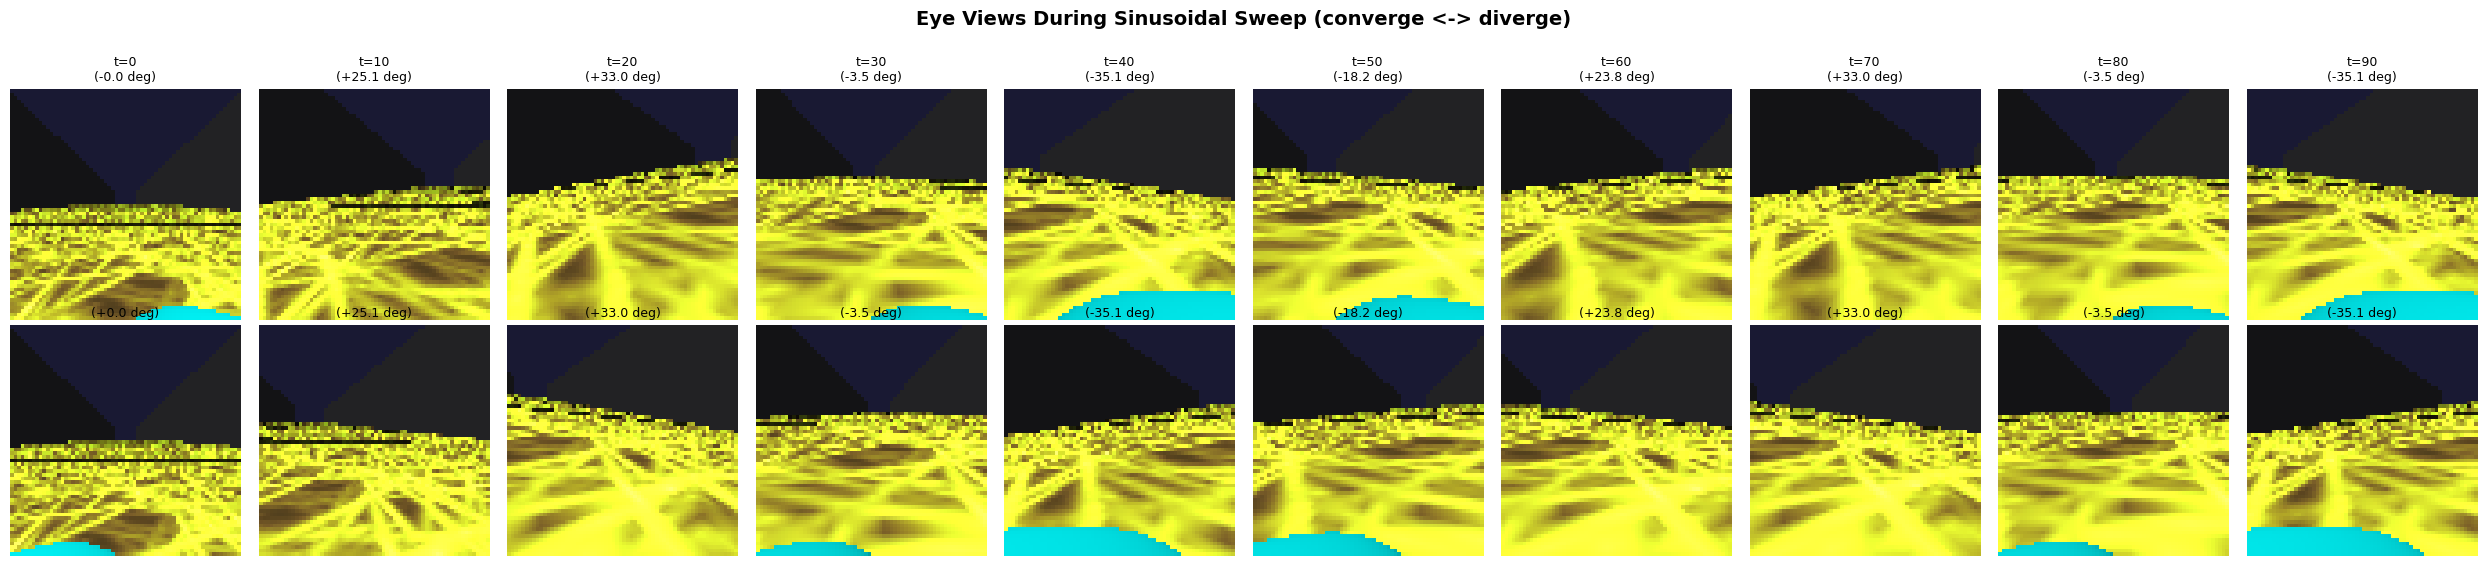

In [10]:
# Plot 2: Rendered frames grid (2 rows: left eye, right eye; 10 columns: timesteps)
n_samples = len(SAMPLE_STEPS)
fig, axes = plt.subplots(2, n_samples, figsize=(2.5 * n_samples, 5.5))

for col, t in enumerate(SAMPLE_STEPS):
    axes[0, col].imshow(sampled_frames_left[t])
    axes[0, col].axis("off")
    angle_l = np.degrees(eye_angle_history[t, 0])
    axes[0, col].set_title(f"t={t}\n({angle_l:+.1f} deg)", fontsize=9)

    axes[1, col].imshow(sampled_frames_right[t])
    axes[1, col].axis("off")
    angle_r = np.degrees(eye_angle_history[t, 1])
    axes[1, col].set_title(f"({angle_r:+.1f} deg)", fontsize=9)

axes[0, 0].set_ylabel("Left Eye", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Right Eye", fontsize=12, fontweight="bold")

plt.suptitle(
    "Eye Views During Sinusoidal Sweep (converge <-> diverge)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

## 6. Comparison: Actuable vs Fixed Cameras

Create a second environment with fixed cameras (the default binocular mode) at
`eye_angle_offset=0.2` and show that the actuable system can reproduce the same
angle -- and go beyond it.

In [11]:
# Create fixed-camera environment
cfg_fixed = default_config()
cfg_fixed.binocular = True
cfg_fixed.actuable_eyes = False
cfg_fixed.eye_angle_offset = 0.2  # ~11.5 deg offset, ~57 deg overlap
cfg_fixed.mujoco_impl = "warp"
cfg_fixed.use_mesh_platforms = True
cfg_fixed.aesthetic = "outdoor_natural"

env_fixed = RunGapVision(config=cfg_fixed)

renderer_fixed_left = JaxVisionRenderer(
    mj_model=env_fixed.mj_model,
    mjx_model=env_fixed.mjx_model,
    nworld=NWORLD,
    width=WIDTH,
    height=HEIGHT,
    grayscale=False,
    render_depth=False,
    use_textures=True,
    use_shadows=True,
    camera_name="eye_left-rodent",
)

renderer_fixed_right = JaxVisionRenderer(
    mj_model=env_fixed.mj_model,
    mjx_model=env_fixed.mjx_model,
    nworld=NWORLD,
    width=WIDTH,
    height=HEIGHT,
    grayscale=False,
    render_depth=False,
    use_textures=True,
    use_shadows=True,
    camera_name="eye_right-rodent",
)

render_fixed_left_jit = jax.jit(renderer_fixed_left.render)
render_fixed_right_jit = jax.jit(renderer_fixed_right.render)

print(f"Fixed env action size: {env_fixed.action_size} (no eye actuators)")
print(
    f"Fixed eye_angle_offset: {cfg_fixed.eye_angle_offset} rad = {np.degrees(cfg_fixed.eye_angle_offset):.1f} deg"
)

Fixed env action size: 38 (no eye actuators)
Fixed eye_angle_offset: 0.2 rad = 11.5 deg


In [12]:
# Run both envs with 30 zero-action steps (matching pose)
state_fixed = jax.jit(env_fixed.reset)(rng)
step_fixed_fn = jax.jit(env_fixed.step)
for _ in range(30):
    state_fixed = step_fixed_fn(state_fixed, jp.zeros(env_fixed.action_size))

# Actuable env: drive eyes to ~0.2 rad outward to match fixed offset
state_act = jax.jit(env.reset)(rng)
# Apply moderate outward divergence for 50 steps
action_match = jp.zeros(env.action_size)
action_match = action_match.at[-2].set(0.5)  # moderate outward for left
action_match = action_match.at[-1].set(0.5)  # moderate outward for right
for _ in range(50):
    state_act = step_fn(state_act, action_match)

act_angles = np.array(state_act.data.qpos[env._eye_qpos_indices])

# Also get actuable at extreme divergence
state_extreme = jax.jit(env.reset)(rng)
action_extreme = jp.zeros(env.action_size)
action_extreme = action_extreme.at[-2].set(1.0)
action_extreme = action_extreme.at[-1].set(1.0)
for _ in range(50):
    state_extreme = step_fn(state_extreme, action_extreme)

extreme_angles = np.array(state_extreme.data.qpos[env._eye_qpos_indices])

print(
    f"Fixed camera offset:         {np.degrees(cfg_fixed.eye_angle_offset):.1f} deg (each eye)"
)
print(
    f"Actuable (matched) angles:   left={np.degrees(act_angles[0]):.1f} deg, right={np.degrees(act_angles[1]):.1f} deg"
)
print(
    f"Actuable (extreme) angles:   left={np.degrees(extreme_angles[0]):.1f} deg, right={np.degrees(extreme_angles[1]):.1f} deg"
)

Module _actuator_velocity__locals__actuator_velocity_85568a88 28986b3 load on device 'cuda:0' took 1.16 ms  (cached)
Module _tendon_velocity__locals__tendon_velocity_b6334b99 08b57ba load on device 'cuda:0' took 1.24 ms  (cached)
Module solve_init_jaref__locals__kernel_c1b08cdd c1b08cd load on device 'cuda:0' took 1.65 ms  (cached)
Module update_constraint_gauss_cost__locals__kernel_1b8477ec 1b8477e load on device 'cuda:0' took 1.18 ms  (cached)
Module linesearch_jv_fused__locals__kernel_53483416 5348341 load on device 'cuda:0' took 1.16 ms  (cached)
Fixed camera offset:         11.5 deg (each eye)
Actuable (matched) angles:   left=20.0 deg, right=20.0 deg
Actuable (extreme) angles:   left=40.0 deg, right=40.0 deg


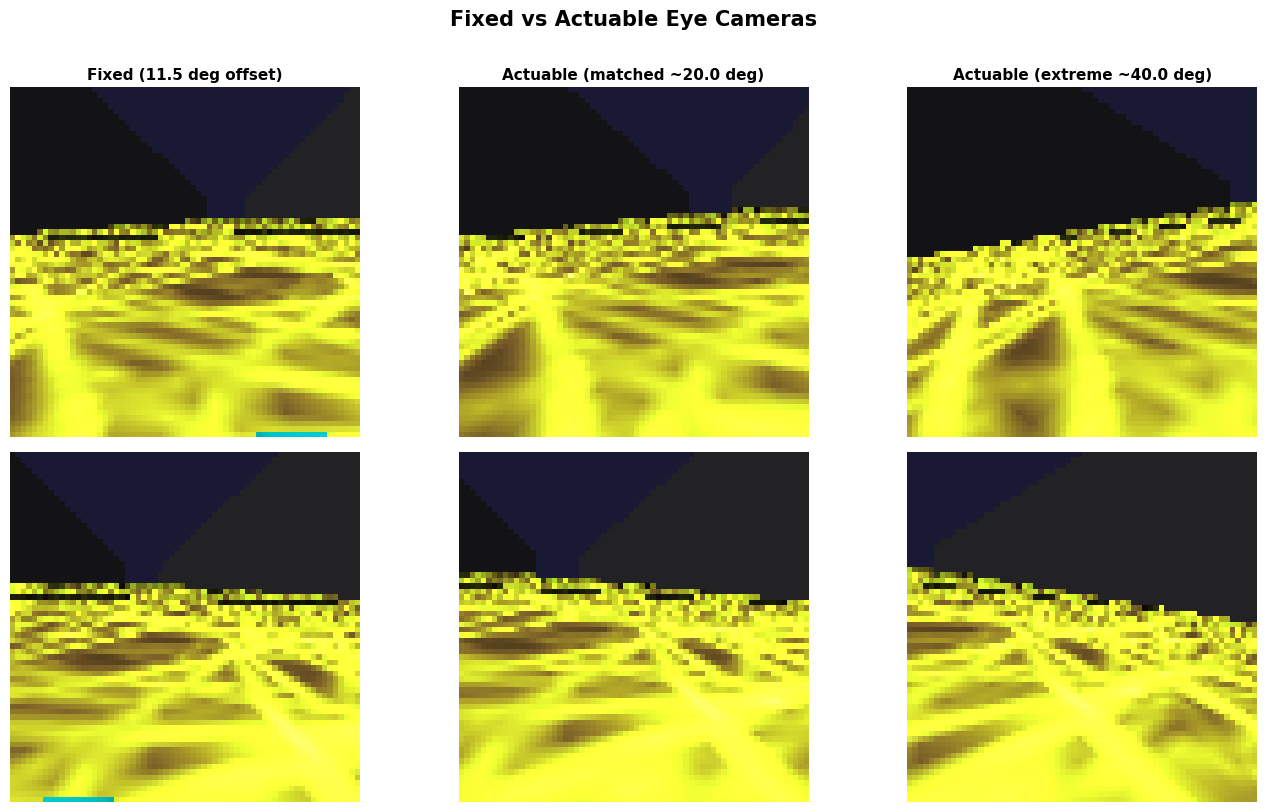

In [13]:
# Render all three conditions
batched_fixed = add_batch_dim(state_fixed.data)
batched_act = add_batch_dim(state_act.data)
batched_extreme = add_batch_dim(state_extreme.data)

fixed_left = np.array(render_fixed_left_jit(batched_fixed)[0])
fixed_right = np.array(render_fixed_right_jit(batched_fixed)[0])
act_left = np.array(render_left_jit(batched_act)[0])
act_right = np.array(render_right_jit(batched_act)[0])
extreme_left = np.array(render_left_jit(batched_extreme)[0])
extreme_right = np.array(render_right_jit(batched_extreme)[0])

# Plot comparison
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

titles = [
    f"Fixed ({np.degrees(cfg_fixed.eye_angle_offset):.1f} deg offset)",
    f"Actuable (matched ~{np.degrees(act_angles[0]):.1f} deg)",
    f"Actuable (extreme ~{np.degrees(extreme_angles[0]):.1f} deg)",
]
left_imgs = [fixed_left, act_left, extreme_left]
right_imgs = [fixed_right, act_right, extreme_right]

for col in range(3):
    axes[0, col].imshow(left_imgs[col])
    axes[0, col].set_title(titles[col], fontsize=11, fontweight="bold")
    axes[0, col].axis("off")

    axes[1, col].imshow(right_imgs[col])
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Left Eye", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Right Eye", fontsize=12, fontweight="bold")

plt.suptitle("Fixed vs Actuable Eye Cameras", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 8. Video: Third-Person Rollout with Eye Vision Overlay

Render a full episode video showing:
- **Main view:** Third-person MuJoCo tracking camera following the rodent
- **Upper-left overlay:** Left eye camera view (red border)
- **Upper-right overlay:** Right eye camera view (blue border)
- **Bottom bar:** Eye angle gauge showing current left/right yaw

The rodent runs with zero body control (falls/slides naturally) while the
eyes follow a scripted pattern: straight ahead → diverge → converge → 
oscillate — demonstrating that the eye cameras physically rotate.

In [14]:
import mujoco
from matplotlib.animation import FFMpegWriter
from IPython.display import Video, display
import matplotlib.gridspec as gridspec

VIDEO_FPS = 50
VIDEO_HEIGHT = 480
VIDEO_WIDTH = 640
EYE_VIS_SCALE = 3  # scale factor for eye vision overlays
N_EPISODE_STEPS = 300
VIDEO_SAVE_PATH = "actuable_eye_rollout.mp4"

# --- Third-person renderer (CPU, from qpos) ---
mj_model = env.mj_model
mj_data = mujoco.MjData(mj_model)
mj_renderer = mujoco.Renderer(mj_model, height=VIDEO_HEIGHT, width=VIDEO_WIDTH)

camera = mujoco.MjvCamera()
camera.type = mujoco.mjtCamera.mjCAMERA_TRACKING
for name in ["torso-rodent", "torso"]:
    try:
        camera.trackbodyid = mj_model.body(name).id
        break
    except Exception:
        continue
camera.distance = 0.8
camera.azimuth = 90
camera.elevation = -20
camera.lookat[:] = [0, 0, 0.25]


def render_third_person(qpos):
    """Render a third-person frame from qpos."""
    mj_data.qpos = qpos
    mujoco.mj_forward(mj_model, mj_data)
    mj_renderer.update_scene(mj_data, camera)
    return mj_renderer.render().copy()


def nn_upscale(img, factor):
    """Nearest-neighbor upscale by integer factor."""
    return np.repeat(np.repeat(img, factor, axis=0), factor, axis=1)


def overlay_eye_views(
    frame,
    img_left,
    img_right,
    scale=EYE_VIS_SCALE,
    left_angle_deg=0.0,
    right_angle_deg=0.0,
):
    """Overlay left/right eye views on the third-person frame with borders and labels."""
    out = frame.copy()
    pad = 4
    border = 2

    for img_raw, color, label, angle_deg, x_anchor in [
        (img_left, (220, 60, 60), "L", left_angle_deg, "left"),
        (img_right, (60, 100, 220), "R", right_angle_deg, "right"),
    ]:
        # Prepare RGB image
        img = (np.clip(img_raw, 0, 1) * 255).astype(np.uint8)
        if img.ndim == 2:
            img = img[:, :, None]
        if img.shape[-1] == 1:
            img = np.repeat(img, 3, axis=-1)
        img = nn_upscale(img, scale)
        sh, sw = img.shape[:2]

        # Position: upper-left for L, upper-right for R
        y0 = pad + border
        if x_anchor == "left":
            x0 = pad + border
        else:
            x0 = out.shape[1] - pad - border - sw
        y1, x1 = y0 + sh, x0 + sw

        if (
            y1 + border < out.shape[0]
            and x1 + border < out.shape[1]
            and x0 - border >= 0
        ):
            # Draw colored border
            out[y0 - border : y1 + border, x0 - border : x1 + border] = color
            # Place image
            out[y0:y1, x0:x1] = img

    return out


def draw_eye_gauge(frame, left_deg, right_deg, max_deg=40.0):
    """Draw a horizontal eye angle gauge bar at the bottom of the frame."""
    out = frame.copy()
    h, w = out.shape[:2]
    bar_h = 40
    bar_y = h - bar_h

    # Semi-transparent dark background
    out[bar_y:, :] = (out[bar_y:, :].astype(float) * 0.3).astype(np.uint8)

    # Center line
    cx = w // 2
    out[bar_y + 5 : bar_y + bar_h - 5, cx : cx + 1] = [180, 180, 180]

    # Scale: pixels per degree
    ppd = (w // 2 - 40) / max_deg

    # Left eye marker (red)
    lx = int(cx + left_deg * ppd)
    lx = np.clip(lx, 10, w - 10)
    out[bar_y + 4 : bar_y + bar_h - 4, lx - 3 : lx + 4] = [220, 60, 60]

    # Right eye marker (blue)
    rx = int(cx - right_deg * ppd)  # negate: positive right = rightward on screen
    rx = np.clip(rx, 10, w - 10)
    out[bar_y + 4 : bar_y + bar_h - 4, rx - 3 : rx + 4] = [60, 100, 220]

    # Tick marks at ±20° and ±40°
    for deg in [-40, -20, 0, 20, 40]:
        tx = int(cx + deg * ppd)
        if 0 <= tx < w:
            out[bar_y + 2 : bar_y + 6, tx : tx + 1] = [140, 140, 140]
            out[bar_y + bar_h - 6 : bar_y + bar_h - 2, tx : tx + 1] = [140, 140, 140]

    return out


# --- Scripted eye control pattern ---
# Phase 1 (0-60): eyes straight ahead
# Phase 2 (60-120): ramp to max diverge
# Phase 3 (120-180): hold max diverge
# Phase 4 (180-210): ramp to max converge
# Phase 5 (210-240): hold max converge
# Phase 6 (240-300): sinusoidal oscillation


def scripted_eye_ctrl(t):
    """Return (left_ctrl, right_ctrl) in [-1, 1] for timestep t."""
    if t < 60:
        return 0.0, 0.0  # straight
    elif t < 120:
        frac = (t - 60) / 60.0
        return frac, frac  # ramp to diverge
    elif t < 180:
        return 1.0, 1.0  # max diverge
    elif t < 210:
        frac = (t - 180) / 30.0
        return 1.0 - 2.0 * frac, 1.0 - 2.0 * frac  # ramp to converge
    elif t < 240:
        return -1.0, -1.0  # max converge
    else:
        # Sinusoidal oscillation
        phase = 2.0 * np.pi * (t - 240) / 40.0
        v = np.sin(phase)
        return v, v


# --- Run episode and render video ---
print(f"Running {N_EPISODE_STEPS}-step episode with scripted eye control...")

state = jax.jit(env.reset)(rng)

# Storage for video frames
qpos_list = [np.array(state.data.qpos)]
eye_left_frames = []
eye_right_frames = []
eye_angle_trace = np.zeros((N_EPISODE_STEPS + 1, 2))
eye_ctrl_trace = np.zeros((N_EPISODE_STEPS + 1, 2))

# Render initial frame
batched_data = add_batch_dim(state.data)
eye_left_frames.append(np.array(render_left_jit(batched_data)[0]))
eye_right_frames.append(np.array(render_right_jit(batched_data)[0]))
eye_angle_trace[0] = np.array(state.data.qpos[env._eye_qpos_indices])

for t in tqdm(range(N_EPISODE_STEPS), desc="Running episode"):
    lc, rc = scripted_eye_ctrl(t)
    eye_ctrl_trace[t + 1] = [lc, rc]

    action = jp.zeros(env.action_size)
    action = action.at[-2].set(lc)
    action = action.at[-1].set(rc)
    state = step_fn(state, action)

    qpos_list.append(np.array(state.data.qpos))
    batched_data = add_batch_dim(state.data)
    eye_left_frames.append(np.array(render_left_jit(batched_data)[0]))
    eye_right_frames.append(np.array(render_right_jit(batched_data)[0]))
    eye_angle_trace[t + 1] = np.array(state.data.qpos[env._eye_qpos_indices])

print(f"Collected {len(qpos_list)} frames.")

# --- Compose video ---
fig_vid, axes_vid = plt.subplots(
    2,
    1,
    figsize=(8, 6.5),
    dpi=100,
    gridspec_kw={"height_ratios": [5, 1.2]},
)

im_main = axes_vid[0].imshow(np.zeros((VIDEO_HEIGHT, VIDEO_WIDTH, 3), dtype=np.uint8))
axes_vid[0].axis("off")
title_main = axes_vid[0].set_title("", fontsize=11, fontweight="bold")

# Timeline subplot
ax_tl = axes_vid[1]
ax_tl.plot(
    np.degrees(eye_angle_trace[:, 0]), color="#D32F2F", linewidth=1.2, label="Left eye"
)
ax_tl.plot(
    np.degrees(eye_angle_trace[:, 1]), color="#1565C0", linewidth=1.2, label="Right eye"
)
ax_tl.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax_tl.set_xlim(0, N_EPISODE_STEPS)
ax_tl.set_ylabel("Eye angle (deg)", fontsize=9)
ax_tl.set_xlabel("Timestep", fontsize=9)
ax_tl.legend(fontsize=8, loc="upper left")
ax_tl.grid(True, alpha=0.3)

# Phase annotations
phases = [
    (0, 60, "Straight"),
    (60, 120, "Ramp diverge"),
    (120, 180, "Max diverge"),
    (180, 210, "Ramp converge"),
    (210, 240, "Max converge"),
    (240, 300, "Oscillate"),
]
colors_phase = ["#E8E8E8", "#FFE0E0", "#FFCCCC", "#E0E0FF", "#CCCCFF", "#E0FFE0"]
for (t0, t1, label), c in zip(phases, colors_phase):
    ax_tl.axvspan(t0, t1, alpha=0.3, color=c)
    ax_tl.text(
        (t0 + t1) / 2,
        ax_tl.get_ylim()[1] * 0.9,
        label,
        ha="center",
        fontsize=7,
        style="italic",
    )

cursor_line = ax_tl.axvline(0, color="black", linewidth=2, zorder=10)

fig_vid.tight_layout()

print(f"Rendering video to {VIDEO_SAVE_PATH}...")
vid_writer = FFMpegWriter(fps=VIDEO_FPS, metadata={"title": "Actuable Eye Rollout"})

with vid_writer.saving(fig_vid, VIDEO_SAVE_PATH, dpi=100):
    for t in range(len(qpos_list)):
        # Third-person frame
        frame = render_third_person(qpos_list[t])

        # Get eye angles for this frame
        l_deg = np.degrees(eye_angle_trace[t, 0])
        r_deg = np.degrees(eye_angle_trace[t, 1])

        # Overlay eye views
        frame = overlay_eye_views(
            frame,
            eye_left_frames[t],
            eye_right_frames[t],
            left_angle_deg=l_deg,
            right_angle_deg=r_deg,
        )

        # Draw eye angle gauge at bottom
        frame = draw_eye_gauge(frame, l_deg, r_deg)

        im_main.set_data(frame)

        # Phase label
        phase_label = ""
        for t0, t1, label in phases:
            if t0 <= t < t1:
                phase_label = label
                break
        title_main.set_text(
            f"Step {t}/{N_EPISODE_STEPS}  |  "
            f"L: {l_deg:+.1f}°  R: {r_deg:+.1f}°  |  {phase_label}"
        )

        cursor_line.set_xdata([t, t])
        vid_writer.grab_frame()

        if (t + 1) % 100 == 0:
            print(f"  {t + 1}/{len(qpos_list)} frames")

plt.close(fig_vid)
print(f"Video saved: {VIDEO_SAVE_PATH}")
print(f"Duration: {len(qpos_list) / VIDEO_FPS:.1f}s at {VIDEO_FPS} fps")

Running 300-step episode with scripted eye control...


Running episode: 100%|██████████| 300/300 [00:21<00:00, 13.79it/s]


Collected 301 frames.
Rendering video to actuable_eye_rollout.mp4...
  100/301 frames
  200/301 frames
  300/301 frames
Video saved: actuable_eye_rollout.mp4
Duration: 6.0s at 50 fps


In [15]:
display(Video(VIDEO_SAVE_PATH, embed=True, width=800))

## 9. Summary

### Key Findings

1. **Eye joints respond to control signals.** The 2 yaw hinge joints on the skull
   reliably rotate in response to the last 2 entries of the action vector. Positive
   control drives both eyes outward (divergence), negative control drives them inward
   (convergence).

2. **Camera views visibly rotate as eye angles change.** The rendered images from
   `eye_left_actuated-rodent` and `eye_right_actuated-rodent` clearly shift as the
   eye joints move, confirming that the cameras are physically attached to the
   actuated mount bodies.

3. **Convergent gaze narrows the binocular field, divergent gaze widens it.** When
   both eyes converge (look inward), the overlap between left and right views
   increases but the total binocular field narrows. Divergence has the opposite
   effect -- wider total field but less overlap.

4. **Actuable cameras subsume fixed cameras.** The actuable system can match any
   fixed eye angle offset and also explore angles beyond the fixed range. This
   makes it strictly more capable than fixed-offset binocular cameras.

5. **The agent could learn to use this for active depth perception.** By controlling
   vergence angle, the agent can optimize its binocular overlap for different
   situations -- wider field for navigation, narrower overlap for precise depth
   estimation at gaps. This is analogous to real rodent eye movements.

### Next Steps

- Train an RL agent with `actuable_eyes=True` and compare gap-crossing performance
  against fixed-camera baselines.
- Analyze learned eye movement policies: does the agent learn to converge when
  approaching gaps (active depth sensing)?
- Compare with biological rodent eye movement data.